# The Growth of K-Pop in the UK: Evidence from Concerts and Online Demand 

### Has K-pop gone mainstream in the UK? Tracing the growth of Korean live music from niche fandom to mainstream cultural presence, 2011–2025.

#### Why the UK?

In the past couple of decades, K-pop (Korean Popular Music) has evolved from a domestically consumed genre into a global cultural phenomenon. Artists such as BTS and BLACKPINK have achieved unprecedented international success, selling out stadiums worldwide and reaching audiences far beyond South Korea. This rise reflects the expansion of one of South Korea’s influential cultural exports, often referred to as the ‘Korean Wave’ or “hallyu” (한류). <br> 

Previously dominated by Western artists, the UK market has increasingly hosted K-pop acts. Since the first K-pop concert in the UK in 2011 by boy group SHINee, numerous K-pop artists have since gone on tour. More famous artists, like BTS, BLACKPINK and Stray Kids, have gone on to sell out major UK venues like Wembley Stadium and Tottenham Hotspur Stadium. But how did we get here, and what does the data actually tell us? <br> 

This project uses a hand-collected dataset of every K-pop concert held in the UK between 2011 and 2025. By examining concert frequency, venue size, and geographic spread over time, this analysis asks whether K-pop in the UK has crossed from niche fandom into mainstream live music culture — and what the evidence suggests about where it is headed next. <br> 

To answer this, the concert data is enriched with two additional sources. Venue capacities — scraped from Wikipedia — allow the scale of events to be tracked over time: a group graduating from a 600-capacity club to a 20,000-seat arena tells a different story to raw concert counts alone. UK Google search interest for 'K-pop', retrieved via Google Trends, provides an independent measure of public awareness, allowing us to ask whether growing concert activity reflects, or perhaps even drives, broader cultural curiosity about the genre. <br> 

Beyond counting concerts, this project also asks where these concerts now take place and who is experiencing growth. For much of K-pop's UK history, London has been the near-exclusive destination for touring artists. Does that remain true as the market matures? If the same artists are returning year after year, does this suggest a loyal and sustained fanbase? These questions are what it means to call a genre truly mainstream: not just growing but remaining.



#### Data Gathering and Limitations  

UK K-pop concerts from 2011 to 2021 were manually compiled using [2010 - 2021 K-concerts in Europe](https://www.kpop-concert.com/k-planning/2010-2021-k-concert-in-europe) . 2022 to 2027 were taken from [Kpop Concerts in Europe](https://www.kpopconcertseurope.com/calendar) and[Hallyu Doing Event Schedule](https://www.hallyudoing.com/event-schedule) . Venue details were cross-referenced using [Concert Archives](https://www.concertarchives.org) , [London Korean Links](https://londonkoreanlinks.net) , [setlist fm](https://www.setlist.fm) and [Ents24](https://www.ents24.com) . <br>

Since the dataset was manually compiled, it is subject to human error. There may be potential typos in artist or venue names, incorrect dates, or omitted concerts. Venue name mismatches may cause merge failures, leaving some capacity values missing. Findings should hence be treated as exploratory rather than definitive. <br> 

The dataset includes 2026 (though incomplete) and 2027 for reference, but the analysis covers only the completed years of 2011-2025. This is due to the high number of K-pop concerts for 2026 already, and some concerts have already been announced for 2027. It covers UK-only shows, with "K-pop" defined broadly to include solo artists, groups, subunits, and festival appearances (BST Hyde Park, Glastonbury). Multi-night runs and multi-city UK tours, as well as cultural festival events such as Korea on Stage in London. <br> 

Where a venue could not be confirmed, entries were commented out of the dataset.  Postponed or cancelled concerts remain in the dataset as they still represent demonstrated demand and industry intent. An artist or their management decided to tour to the UK, tickets went on sale, and fans bought them. Removing them would undercount actual K-pop activity in the UK during this period. Reasons for cancelation varied with K-pop Flex in London (2022) cancelled following the Itaewon tragedy [Son et al 2025](https://doi.org/10.1016/j.ssci.2024.106741) ). Others were cancelled due to organisational failure or health reasons. <br> 

A notable data cleaning challenge was venue name changes over time. The OVO Arena Wembley appears in earlier entries as the SSE Arena Wembley, reflecting its sponsorship history. Similarly, Brixton Academy became known as the O2 Academy Brixton. All venue names were normalised to their current venue name prior to analysis. 



In [562]:
!pip install pytrends pandas matplotlib seaborn statsmodels requests beautifulsoup4

In [563]:
# importing all the needed packages for my project 

# basic package in Python 
import pandas as pd 

# needed to create the necessary graphs for analysis (bar chart, line graph, pie chart)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 
import matplotlib.ticker as ticker 

# needed for Google Trends data 
from pytrends.request import TrendReq 

# needed for web scraping to collect data information off Wikipedia about concert venue capacities 
import requests
import urllib.request 
from bs4 import BeautifulSoup
import time
import re 

# needed for regressions 
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm   

In [564]:
# Manual collection of data on K-pop concerts held in the UK from 2011 to 2025 to create a dataset. 
# It also includes 2026 (incomplete year) and 2027, which already has some concerts announced. 
# Some of the rows in the dataset have missing venue information so is not included in the running of the code by placing # in front of it. 

concert_data = [
    # 2011–2013 (the beginning)
    ["SHINee", "2011-11-03", "London", "Odeon West End Theatre"],
    ["United Cube in London", "2011-12-05", "London", "Brixton Academy"], 

    ["MBC London Korean Cultural Festival 2012", "2012-06-23", "London", "IndigO2"], 
    ["CNBLUE", "2012-09-22", "London", "IndigO2"], 
    ["BIG BANG", "2012-12-14", "London", "SSE Wembley Arena"],
    ["BIG BANG", "2012-12-15", "London", "SSE Wembley Arena"],
    
    ["TEEN TOP", "2013-02-08", "London", "The Forum"],
    ["Jay Park", "2013-09-21", "London", "Hammersmith Apollo"],
    ["Korean Brand & Entertainment Expo", "2013-11-04", "London", "Old Billingsgate"], 
    ["Korean Brand & Entertainment Expo", "2013-11-05", "London", "Old Billingsgate"], 
    ["Korean Brand & Entertainment Expo", "2013-11-06", "London", "Old Billingsgate"], 
    ["Super Junior", "2013-11-09", "London", "SSE Wembley Arena"],
    ["INFINITE", "2013-11-27", "London", "Hammersmith Apollo"],

    # 2014–2017 (slow growth)
    ["B.A.P", "2014-04-27", "London", "O2 Academy Brixton"],
    ["UKISS", "2014-09-24", "London", "Forum Kentish Town"], 
    
    ["Boys Republic", "2015-07-04", "London", "O2 Academy Islington"],
    ["TOPPDOGG", "2015-09-04", "London", "Troxy"], 
    ["INFINITE", "2015-10-09", "London", "O2 Shepherd's Bush Empire"], 

    ["HISTORY", "2016-02-20", "London", "O2 Academy Islington"], 
    ["B.A.P", "2016-05-13", "London", "The Coronet Theatre"], 
    ["MYNAME", "2016-09-10", "London", "O2 Academy Islington"], 

    ["Zico", "2017-01-05", "London", "KOKO"], 
    ["24K", "2017-01-06", "London", "229 The Venue"], 
    ["Zion.T", "2017-02-17", "London", "O2 Forum Kentish Town"], 
    ["BLOCK B", "2017-03-05", "London", "Troxy"], 
    ["DEAN", "2017-06-24", "London", "KOKO"], 
    ["London Korean Festival", "2017-07-08", "London", "Olympia"], 
    ["24K", "2017-08-09", "London", "KOKO"],
    ["K.A.R.D", "2017-09-01", "London", "ULU Live"],
    ["G-Dragon", "2017-09-23", "Birmingham", "Genting Arena"], 
    ["G-Dragon", "2017-09-24", "London", "SSE Arena Wembley"],

    # 2018–2019 (rapid growth)
    ["ALPHABAT", "2018-01-29", "London", "Camden Assembly"],
    ["Jay Park", "2018-02-04", "London", "Troxy"], 
    ["DREAMCATCHER", "2018-02-14", "London", "ULU Live"],
    ["The Rose", "2018-02-24", "London", "ULU Live"], 
    ["HALO", "2018-03-11", "London", "229 The Venue"],
    ["VAV", "2018-03-25", "London", "229 The Venue"], 
    ["SOUTH CLUB", "2018-04-20", "London", "Underworld Camden"], 
    ["PENEMECO", "2018-05-13", "London", "Scala"], 
    ["G2", "2018-05-25", "London", "Lightbox"], 
    ["Flowsik", "2018-06-03", "Glasgow", "The Classic Grand"], 
    ["MONSTA X", "2018-06-17", "London", "Hammersmith Apollo"],
    ["AOMG", "2018-07-21", "London", "Troxy"], 
    ["BIGONE", "2018-08-30", "London", "The Fiddler's Elbow"], 
    ["VICTON", "2018-09-13", "London", "229 The Venue"],
    ["UP10TION", "2018-09-23", "London", "229 The Venue"],
    ["ZICO", "2018-09-28", "London", "O2 Shepherd's Bush Empire"],
    ["RAVI", "2018-11-09", "London", "Fire & Lightbox Complex"], 
    ["JESSI", "2018-11-16", "London", "O2 Academy Islington"], 
    ["BTS", "2018-10-09", "London", "The O2 Arena"],
    ["B.A.P", "2018-12-02", "London", "Troxy"],
    ["DPR", "2018-11-11", "London", "Oval Space"], 
    ["Simon Dominic", "2018-12-02", "London", "Indigo at The O2"], 

    ["DAY6", "2019-01-25", "London", "O2 Forum Kentish Town"], 
    ["CRUSH", "2019-01-20", "London", "O2 Forum Kentish Town"], 
    ["Hyolyn", "2019-02-23", "London", "Electric Ballroom"], 
    ["A.C.E", "2019-03-10", "London", "O2 Academy Islington"], 
    ["BANG YONGGUK", "2019-03-27", "London", "The Underworld Camden"], 
    ["EPIK HIGH", "2019-04-20", "London", "Electric Ballroom"], 
    ["Sik-K", "2019-03-23", "Manchester", "Factory"], 
    ["Sik-K", "2019-03-24", "London", "Electric Ballroom"], 
    ["ATEEZ", "2019-04-03", "London", "O2 Forum Kentish Town"],
    ["Seven O'Clock", "2019-04-06", "London", "The Garage"], 
    ["Sam Kim", "2019-04-28", "London", "Electric Ballroom"], 
    ["SF9", "2019-05-12", "London", "O2 Shepherd's Bush Empire"], 
    ["BLACKPINK", "2019-05-21", "Manchester", "Manchester Arena"], 
    ["BLACKPINK", "2019-05-22", "London", "SSE Arena Wembley"],
    ["SUNMI", "2019-05-30", "London", "Indigo at The O2"], 
    ["BTS", "2019-06-01", "London", "Wembley Stadium"],
    ["BTS", "2019-06-02", "London", "Wembley Stadium"],
    ["Eric Nam", "2019-06-21", "London", "O2 Academy Islington"],
    ["Eric Nam", "2019-06-22", "London", "O2 Academy Islington"], 
    ["MASC", "2019-06-28", "London", "The Garage"], 
    ["IMJM", "2019-06-29", "London", "Oval Space"], 
    ["NCT 127", "2019-07-27", "London", "SSE Arena Wembley"], 
    ["Monsta X", "2019-07-09", "London", "SSE Arena Wembley"], 
    ["KNK", "2019-08-18", "London", "O2 Academy Islington"], 
    ["N.TIC", "2019-10-01", "London", "Streatham Space Project"], 
    ["VIOLET TREE", "2019-10-06", "London", "The Underworld Camden"], 
    ["GOT7", "2019-10-11", "London", "SSE Arena Wembley"], 
    ["DJ Hyo", "2019-10-17", "London", "Ministry of Sound"], 
    ["Jay Park", "2019-10-20", "London", "Olympia"], 
    ["Stray Kids", "2019-07-28", "London", "O2 Academy Brixton"], 
    ["LUCENTE", "2019-09-08", "London", "229 The Venue"], 
    ["DREAMCATCHER", "2019-10-24", "London", "ULU Live"], 
    ["GOT7", "2019-10-11", "London", "SSE Wembley Arena"],
    ["VAV", "2019-11-24", "London", "O2 Academy Islington"],
    ["The Rose", "2019-11-24", "London", "Scala"], 
    ["The Rose", "2019-11-25", "London", "Scala"], 
    ["The Rose", "2019-11-27", "Manchester", "Manchester Academy"], 
    #["ALPHABATA", "2019-12-12", "London", ""], 
    ["The Boyz", "2019-12-18", "London", "O2 Forum Kentish Town"],
    ["HOLLAND", "2019-12-15", "London", "ULU Live"], 

    # 2020–2021 (Covid-19 drop)
    ["DAY6", "2020-01-12", "London", "O2 Academy Brixton"],
    ["ONE", "2020-02-23", "London", "XOYO"], 
    ["AB6IX", "2020-02-26", "London", "Indigo at The O2"], 
    ["SuperM", "2020-02-28", "London", "The O2 Arena"],
    
    ["CL", "2021-11-30", "London", "XOYO"],
    ["BLOO", "2021-12-03", "London", "The Garage"], 

    # 2022–2025 (boom period)
    ["Eric Nam", "2022-04-10", "Glasgow", "The Barrowland Ballroom"],
    ["MCND", "2022-04-10", "London", "O2 Academy"],
    ["Eric Nam", "2022-04-12", "Manchester", "O2 Ritz"],
    ["Eric Nam", "2022-04-13", "London", "O2 Forum Kentish Town"],
    ["Eric Nam", "2022-04-14", "London", "O2 Shepherd's Bush Empire"],
    ["ATEEZ", "2022-04-30", "London", "OVO Arena, Wembley"],
    ["ATEEZ", "2022-05-01", "London", "OVO Arena, Wembley"],
    ["THE BOYZ", "2022-06-20", "London", "OVO Arena, Wembley"],
    ["Kim Woojin", "2022-08-03", "London", "O2 Academy Islington"],
    ["SUNMI", "2022-08-21", "London", "Troxy"], 
    ["Wonho", "2022-09-04", "London", "Indigo at The O2"],
    ["LOONA", "2022-09-16", "London", "O2 Academy Brixton"],
    ["Hallyu Con", "2022-10-01", "London", "Samsung KX"],
    ["JESSI", "2022-10-10", "London", "Troxy"],
    ["W24", "2022-10-10", "London", "XOYO"],
    ["W24", "2022-10-11", "Birmingham", "The Castle & Falcon"],
    ["W24", "2022-10-12", "Manchester", "Rebellion Manchester"],
    ["PIXY", "2022-10-17", "London", "O2 Academy Islington"], 
    ["DPR", "2022-11-13", "London", "Troxy"],
    ["KPop Flex", "2022-11-20", "London", "The O2 Arena"],
    ["DREAMCATCHER", "2022-11-22", "London", "O2 Academy Brixton"],
    ["BLACKPINK", "2022-11-30", "London", "The O2 Arena"],
    ["BLACKPINK", "2022-12-01", "London", "The O2 Arena"],
    ["JAY B", "2022-12-14", "London", "Indigo at The O2"], 

    ["JACKSON", "2023-01-12", "London", "Eventim Apollo"],
    ["CIX", "2023-01-20", "London", "O2 Forum Kentish Town"],
    ["Sik-K", "2023-01-22", "London", "O2 Forum Kentish Town"],
    ["Kang Daniel", "2023-01-26", "Manchester", "The O2 Ritz"],
    ["Kang Daniel", "2023-01-27", "London", "O2 Shepherd's Bush Empire"],
    ["EPIK HIGH", "2023-02-12", "London", "Troxy"],
    ["KISU", "2023-02-14", "London", "Kingfisher Centre"],
    ["The Rose", "2023-02-14", "London", "O2 Forum Kentish Town"],
    ["ATEEZ", "2023-02-22", "London", "The O2 Arena"],
    ["AOMG", "2023-03-10", "London", "Eventim Apollo"],
    ["JUNNY", "2023-03-12", "London", "The Lafayette"],
    ["NCT DREAM", "2023-04-28", "London", "OVO Arena, Wembley"],
    ["LUMINOUS", "2023-04-30", "London", "O2 Islington Academy"],
    ["BLOO", "2023-05-14", "London", "KOKO"],
    ["Xodiac", "2023-06-01", "London", "Clapham Grand"],
    ["RED VELVET", "2023-06-06", "London", "OVO Arena, Wembley"],
    ["Lee Seong Jong", "2023-06-23", "London", "Conway Hall"],
    ["Bang Yongguk", "2023-07-01", "London", "Dingwalls"],
    ["BLACKPINK", "2023-07-02", "London", "BST Hyde Park"],
    ["The Rose", "2023-07-02", "London", "BST Hyde Park"],
    ["ODD EYE CIRCLE", "2023-08-05", "London", "O2 Forum Kentish Town"],
    ["KARD", "2023-09-06", "London", "Electric Ballroom"],
    ["TWICE", "2023-09-07", "London", "The O2 Arena"],
    ["TWICE", "2023-09-08", "London", "The O2 Arena"],
    ["(G)I-DLE", "2023-09-09", "London", "OVO Arena, Wembley"],
    ["OceanFromTheBlue", "2023-09-21", "London", "O2 Islington Academy"],
    ["ADOY", "2023-09-25", "London", "O2 Academy Islington"],
    ["Se Seo Neon", "2023-09-26", "London", "Scala"],
    ["B.I", "2023-10-15", "London", "Troxy"],
    ["LUMINOUS", "2023-10-15", "London", "Dingwalls"],
    ["Yugyeom", "2023-11-02", "London", "Troxy"],
    ["Lee Seong Jong", "2023-11-03", "London", "Lower Deck, Greenwich Students Union"],
    ["Korea on Stage", "2023-11-08", "London", "OVO Arena, Wembley"],
    ["XDINARY HEROES", "2023-11-13", "London", "O2 Academy Islington"],
    ["VAV", "2023-11-20", "London", "O2 Academy Islington"],
    ["PIXY", "2023-11-26", "London", "The Garage"],
    ["WOODZ", "2023-11-26", "London", "Troxy"],
    ["GEMINI", "2023-12-03", "London", "Heaven"],
   # ["Soul Therapy x You.will.knovv", "2023-12-10", "London", ""],
    
    ["BIGONE, Do Hanse, DIVE", "2024-01-07", "London", "The Garage"],
    ["P1Harmony", "2024-01-12", "London", "Troxy"],
    ["Jimmy Brown x Rovv", "2024-01-19", "London", "Oslo Hackney"],
    ["MCND", "2024-01-25", "London", "O2 Academy"],
    ["Rolling Quartz", "2024-01-26", "London", "O2 Islington"],
    ["XIKERS", "2024-01-28", "London", "O2 Shepherd's Bush"],
    ["EVERGLOW", "2024-01-30", "London", "O2 Shepherd's Bush"],
    ["AMBER", "2024-01-30", "London", "O2 Academy Islington"],
    ["OWAVE", "2024-02-12", "London", "The Garage"],
    ["Corbyn x LXX", "2024-02-18", "London", "The lower third"],
    ["DREAMCATCHER", "2024-02-21", "London", "Troxy"],
    ["CAMO", "2024-03-03", "London", "The Garage"],
    ["STAYC", "2024-03-03", "London", "Troxy"],
    ["CAMO", "2024-03-04", "Manchester", "Manchester Academy"],
    ["Eric Nam", "2024-03-22", "Glasgow", "O2 Academy Glasgow"],
    ["TRENDZ", "2024-03-23", "London", "229"],
    ["Eric Nam", "2024-03-24", "Dublin", "Olympia"],
    ["BAMBAM", "2024-03-24", "London", "O2 Forum Kentish Town"],
    ["Eric Nam", "2024-03-25", "Manchester", "Manchester Academy"],
    ["Eric Nam", "2024-03-26", "London", "Eventim Apollo"],
    ["iKON", "2024-03-28", "London", "Troxy"],
    ["The Rose", "2024-03-30", "London", "OVO Arena, Wembley"],
    ["HAONOAH", "2024-05-05", "London", "The Garage"],
    ["wave to earth", "2024-04-08", "Manchester", "Canva"],
    ["wave to earth", "2024-04-07", "Glasgow", "Classic Grand"],
    ["wave to earth", "2024-04-10", "London", "Electric Brixton"],
    ["Mark Tuan", "2024-05-13", "London", "Indigo at The O2"],
    ["ITZY", "2024-05-24", "London", "OVO Arena, Wembley"],
    ["OnlyOneOf", "2024-06-02", "London", "Heaven"],
    ["TRI.BE", "2024-06-11", "London", "Brixton Jamm"],
    ["IVE", "2024-06-16", "London", "The O2 Arena"],
    ["IU", "2024-06-21", "London", "OVO Arena, Wembley"],
    ["SEVENTEEN", "2024-06-28", "Glastonbury", "Glastonbury Festival"],
    ["AB6IX", "2024-06-29", "London", "The Dome"],
    ["BALMING TIGER", "2024-07-02", "London", "Heaven"],
    ["Tabber x Miso", "2024-07-12", "London", "Heaven, Under the Arches"],
    ["STRAY KIDS", "2024-07-14", "London", "BST Hyde Park"],
    ["NMIXX", "2024-07-14", "London", "BST Hyde Park"],
    ["BILLLIE", "2024-07-21", "London", "Troxy"],
    ["I.M", "2024-07-26", "London", "O2 Shepherd's Bush Empire"],
    ["Suho", "2024-09-10", "London", "Indigo at The O2"],
    ["B.D.U", "2024-09-12", "London", "EartH Hall"],
    ["DYNAMIC DUO", "2024-09-13", "London", "The Steel Yard"],
    ["THE BOYZ", "2024-09-15", "London", "OVO Arena, Wembley"],
    ["W24", "2024-09-22", "London", "New Cross In"],
    ["DKB", "2024-10-02", "London", "EartH Hall"],
    ["B.I", "2024-10-04", "London", "OVO Arena, Wembley"],
    ["Madmans Esprit", "2024-10-08", "London", "The Underworld, Camden"],
    ["Sion", "2024-10-13", "London", "The lower third"], 
    ["A.C.E", "2024-10-17", "London", "EartH Hall"],
    ["Bang Yongguk", "2024-10-20", "London", "Dingwalls"],
    ["ARTMS", "2024-10-23", "London", "Indigo at The O2"],
    ["DPR", "2024-10-27", "London", "OVO Arena, Wembley"],
    ["Woosung", "2024-10-30", "London", "Troxy"],
    ["Hypnosis Therapy", "2024-11-02", "Bristol", "The Lanes"],
    ["Hypnosis Therapy", "2024-11-03", "Leeds", "Headrow House"],
    ["Hypnosis Therapy", "2024-11-04", "London", "Shackelwell Arms"],
    ["NCT DREAM", "2024-11-12", "London", "OVO Arena, Wembley"],
    ["XG", "2024-11-18", "Manchester", "O2 Victoria Warehouse"],
    ["XG", "2024-11-19", "London", "OVO Arena, Wembley"],
    ["KARD", "2024-11-26", "Birmingham", "O2 Academy Birmingham"],
    ["Jey & Khakii", "2024-12-09", "London", "Outernet"],
    ["Yves", "2024-12-09", "London", "O2 Shepherd's Bush Empire"],
    
    ["P1Harmony", "2025-01-13", "London", "Troxy"],
    ["Rolling Quartz", "2025-01-17", "London", "The Garage"],
    ["ATEEZ", "2025-01-27", "London", "The O2 Arena"],
    ["ATEEZ", "2025-01-28", "London", "The O2 Arena"],
    ["Lee Youngji", "2025-01-30", "London", "Clapham Grand"],
    ["ATEEZ", "2025-01-30", "Manchester", "AO Arena"],
    ["AESPA", "2025-03-02", "London", "The O2 Arena"],
    ["Colde", "2025-03-04", "London", "Clapham Grand"],
    ["Kiss of Life", "2025-03-06", "London", "Indigo at The O2"],
    ["Kiss of Life", "2025-03-08", "Glasgow", "O2 Academy Glasgow"],
    ["Taemin", "2025-03-09", "London", "Troxy"],
    ["GHOST9", "2025-03-10", "London", "O2 Academy Islington"],
    ["Jooyoung", "2025-03-14", "London", "The Mirror Arch"],
    ["Taemin", "2025-03-18", "Manchester", "AO Arena"],
    ["TOMORROW X TOGETHER", "2025-03-25", "London", "The O2 Arena"],
    ["BIG OCEAN", "2025-04-24", "London", "The Underworld, Camden"],
    ["wave to earth", "2025-04-29", "London", "O2 Academy Brixton"],
    ["ARTMS", "2025-05-01", "London", "Troxy"],
    ["wave to earth", "2025-05-02", "Manchester", "Manchester Academy"],
    ["Kang Daniel", "2025-05-07", "London", "Islington Assembly Hall"],
    ["Hypnosis Therapy", "2025-05-14", "London", "Strongroom Bar"],
    ["W24", "2025-05-30", "London", "Studio 9294"],
    ["TRENDZ", "2025-06-04", "London", "The Underworld, Camden"],
    ["TIOT", "2025-06-14", "London", "The Courtyard Theatre"],
    ["The Rose", "2025-06-17", "London", "Indigo at The O2"],
    ["The Rose", "2025-06-18", "London", "Indigo at The O2"],
    ["SM Town", "2025-06-28", "London", "The O2 Arena"],
    ["8TURN", "2025-07-13", "London", "Islington Assembley Hall"],
    ["STRAY KIDS", "2025-07-18", "London", "Tottenham Hotspur Stadium"],
    ["STRAY KIDS", "2025-07-19", "London", "Tottenham Hotspur Stadium"],
    ["DPR Cream and DPR Artic", "2025-07-18", "London", ""],
    ["GSOUL", "2025-07-18", "London", "Fire Nightclub"],
    ["GSOUL", "2025-07-20", "Manchester", "Area Manchester"],
    ["Baekhyun", "2025-07-22", "London", "OVO Arena, Wembley"],
    ["from20 x HELLO GLOOM", "2025-07-28", "London", "The Garage"],
    ["Jin", "2025-08-05", "London", "The O2 Arena"],
    ["Jin", "2025-08-06", "London", "The O2 Arena"],
    ["BLACKPINK", "2025-08-15", "London", "Wembley Stadium"],
    ["BLACKPINK", "2025-08-16", "London", "Wembley Stadium"],
    ["ENHYPEN", "2025-08-22", "London", "The O2 Arena"],
    ["ENHYPEN", "2025-08-25", "Manchester", "AO Arena"],
    ["Balming Tiger", "2025-08-23", "Reading", "Reading and Leeds Festival"], 
    ["Balming Tiger", "2025-08-28", "London", "KOKO"],
    ["Wonho", "2025-09-11", "London", "O2 Shepherd's Bush Empire"],
    ["BLOO", "2025-09-19", "London", "The Clapham Grand"],
    ["N.Flying", "2025-10-01", "London", "Indigo at The O2"],
    ["Cotoba", "2025-10-03", "London", "The Lexington"],
    ["Junny", "2025-10-05", "London", "EartH Hall"],
    ["Se Seo Neon", "2025-10-14", "Manchester", "Manchester Academy"],
    ["Se Seo Neon", "2025-10-15", "London", "Heaven"],
    ["SF9", "2025-10-15", "London", "Indigo at The O2"],
    ["Hwasa", "2025-10-26", "London", "Troxy"],
    ["EVNNE", "2025-10-28", "London", "EartH Hall"],
    ["ONEW", "2025-11-11", "London", "Indigo at The O2"],
    ["Sion", "2025-12-01", "London", "The lower third"],
    ["ONEUS", "2025-12-13", "London", "Indigo at The O2"],

    #2026 is an incomplete year so won't be included in the main analysis. 
    # But you can already see the number rivals 2025 when more announcements can still take place.   
    ["ARTMS", "2026-01-13", "London", "O2 Forum Kentish Town"],
    ["Madmans Esprit", "2026-01-14", "London", "The Underworld, Camden"],
    ["P1Harmony", "2026-01-30", "London", "OVO Arena, Wembley"],
    ["KINO", "2026-02-08", "London", "The Garage"],
    ["XLOV", "2026-02-08", "London", "Troxy"],
    ["LNGSHOT Fansign", "2026-02-09", "London", "Snaplab"],
    ["XLOV", "2026-02-11", "Wolverhampton", "The Halls"],
    ["XLOV", "2026-02-12", "Manchester", "Manchester Academy"],
    ["Lee Minyuk (HUTA)", "2026-02-28", "London", "Dingwalls"],
    ["TRENDZ", "2026-03-04", "Edinburgh", "The Liquid Room"],
    ["JUSTB", "2026-03-12", "London", "Islington Assembly Hall"],
    ["NMIXX", "2026-03-26", "London", "Eventim Apollo"],
    ["82MAJOR", "2026-03-29", "London", "EartH Hall"],
    ["2Z", "2026-04-03", "London", "The Courtyard Theatre"],
    ["Cloudian", "2026-04-04", "London", "The Courtyard Theatre"],
    ["JUNHEE", "2026-04-10", "London", "Oslo Hackney"],
    ["JUNHEE Fansign", "2026-04-12", "London", "The Garage"],
    ["1VERSE", "2026-04-13", "London", "The Garage"],
    ["KTAM Unleased", "2026-04-16", "London", "93 Feet East"],
    ["YVES", "2026-04-16", "Manchester", "Manchester Academy"],
    ["Rovv, Twlv, Meloh", "2026-04-17", "London", "Oslo Hackney"],
    ["GAHO & Kave", "2026-04-18", "London", "The Underworld, Camden"],
    ["KTAM Unleased", "2026-04-18", "Brighton", "Daltons"],
    ["Rolling Quartz", "2026-04-19", "London", "The Garage"],
    ["KTAM Unleased", "2026-04-19", "Brighton", "KOMEDIA"],
    ["KTAM Unleased", "2026-04-22", "Brighton", "KOMEDIA"],
    ["KTAM Unleased", "2026-04-24", "London", "Chats Palace Arts Centre"],
    ["KTAM Unleased", "2026-04-25", "London", "Chats Palace Arts Centre"],
    ["EL CAPITXN", "2026-04-25", "London", "The Steel Yard"],
    ["DEPT", "2026-04-27", "London", "The Grace"],
    ["EL CAPITXN", "2026-05-02", "London", "The Courtyard Theatre"],
    ["BIG OCEAN", "2026-05-05", "London", "The Steel Yard"],
    ["ONE PACT", "2026-05-18", "London", "Islington Assembly Hall"],
    ["XDINARY HEROES", "2026-05-31", "Manchester", "O2 Ritz"],
    ["XDINARY HEROES", "2026-06-02", "London", "O2 Forum Kentish Town"],
    ["TWICE", "2026-06-03", "London", "The O2 Arena"],
    ["TWICE", "2026-03-04", "London", "The O2 Arena"],
    ["WOODZ", "2026-06-10", "London", "Troxy"],
    ["The Rose", "2026-06-30", "London", "Eventim Apollo"],
    ["CNBLUE", "2026-07-05", "London", "Troxy"],
    ["BTS", "2026-07-06", "London", "Tottenham Hotspur Stadium"],
    ["BTS", "2026-07-07", "London", "Tottenham Hotspur Stadium"],
    ["Lee Youngji", "2026-10-18", "London", "Clapham Grand"],
    ["LE SSERAFIM", "2026-10-16", "London", "TBA"],

    #2027 K-pop concerts already appeared. Some are being announced a year in advance now. 
    ["AESPA", "2027-01-14", "Manchester", "AO Arena"],
    ["AESPA", "2027-01-16", "London", "The O2 Arena"],
    ["ENHYPEN", "2027-03-09", "London", "The O2 Arena"],
    
     ]
    
    
   

concerts = pd.DataFrame(concert_data, columns = ["artist", "date", "city", "venue"])
concerts.head(10)    # To check the information I have and see if it looks like it should 

,artist,date,city,venue
0,SHINee,2011-11-03,London,Odeon West End Theatre
1,United Cube in London,2011-12-05,London,Brixton Academy
2,MBC London Korean Cultural Festival 2012,2012-06-23,London,IndigO2
3,CNBLUE,2012-09-22,London,IndigO2
4,BIG BANG,2012-12-14,London,SSE Wembley Arena
5,BIG BANG,2012-12-15,London,SSE Wembley Arena
6,TEEN TOP,2013-02-08,London,The Forum
7,Jay Park,2013-09-21,London,Hammersmith Apollo
8,Korean Brand & Entertainment Expo,2013-11-04,London,Old Billingsgate
9,Korean Brand & Entertainment Expo,2013-11-05,London,Old Billingsgate


In [565]:
# Venue Name Normalisation 
# To standardises all different names that the same physical venue may have had, to just one cannonical name. 
# This happens because of sponsorship rebrands (e.g. SSE Arena became the OVO Arena Wembley) 
# and minor inconsistencies in how venues were recorded would cause them to be treated as separate places.

 
venue_name_map = {
    # Wembley Arena — three naming variants → one canonical name
    "SSE Wembley Arena":               "OVO Arena Wembley",
    "SSE Arena Wembley":               "OVO Arena Wembley",
    "OVO Arena, Wembley":              "OVO Arena Wembley",
 
    # O2 Academy Islington variants
    "O2 Islington Academy":            "O2 Academy Islington",
    "O2 Islington":                    "O2 Academy Islington",
 
    # O2 Shepherd's Bush variants
    "O2 Shepherd's Bush":              "O2 Shepherd's Bush Empire",
 
    # Indigo at The O2 variants
    "IndigO2":                         "Indigo at The O2",
 
    # Hammersmith Apollo → current name
    "Hammersmith Apollo":              "Eventim Apollo",
 
    # Forum variants
    "Forum Kentish Town":              "O2 Forum Kentish Town",
    "The O2 Ritz":                     "O2 Ritz",
 
    # Manchester Arena → AO Arena rebrand
    "Manchester Arena":                "AO Arena",
 
    # Brixton Academy → current O2 name
    "Brixton Academy":                 "O2 Academy Brixton",
 
    # Underworld Camden variants
    "The Underworld Camden":           "The Underworld, Camden",
    "Underworld Camden":               "The Underworld, Camden",
 
    # The Clapham Grand variant
    "The Clapham Grand":               "Clapham Grand",

    # The Classic Grand variant
    "The Classic Grand":               "Classic Grand",

    # The Lower Third (upper vs lower case inconsistencies)
    "The Lower Third":                      "The Lower Third",
    "The lower third":                      "The Lower Third",

    # Heaven (two names in the dataset)
    "Heaven, Under the Arches":                      "Heaven",

    # O2 Academy (generic — assume Brixton if London)
    "Islington Assembley Hall":                      "Islington Assembly Hall",
 
    # O2 Academy (generic — assume Brixton if London)
    "O2 Academy":                      "O2 Academy Brixton",
}
 
concerts["venue"] = concerts["venue"].replace(venue_name_map)

# Verify the normalisation worked
print("Unique Wembley arena entries after cleaning:")
print(concerts[concerts["venue"].str.contains("Wembley", na = False)]["venue"].unique())

print("✓ Venue Names Normalised")
print(f"  Number of unique venues before normalisation would have been higher.")
print(f"  Unique venues after normalisation: {concerts['venue'].nunique()}\n")

Unique Wembley arena entries after cleaning:
['OVO Arena Wembley' 'Wembley Stadium']
✓ Venue Names Normalised
  Number of unique venues before normalisation would have been higher.
  Unique venues after normalisation: 86



In [566]:
# Date Parsing & Derived Columns 
# Converts the date column to datetime, extracts year and month, and flags rows with missing or unparseable dates for transparency.

 
concerts["date"] = pd.to_datetime(concerts["date"], errors="coerce")
concerts["year"]  = concerts["date"].dt.year.astype("Int64")   # Int64 supports NaN
concerts["month"] = concerts["date"].dt.month.astype("Int64")
 
# Flag and report missing dates
missing_dates = concerts[concerts["date"].isna()]
if not missing_dates.empty:
    print(f" {len(missing_dates)} row(s) have unparseable dates and will be excluded from time-based analysis:")
    print(missing_dates[["artist", "venue", "city"]])
else:
    print("✓ Dates successfully parsed")
 
print(f"  Date range: {concerts['date'].min().date()} → {concerts['date'].max().date()}\n")


✓ Dates successfully parsed
  Date range: 2011-11-03 → 2027-03-09



In [567]:
# Split Dataset Information Into Analysis Subsets 
# There are three distinct temporal groups:
#   - 2011–2025: complete years used for all main analysis
#   - 2026:      partial year (ongoing) — noted in blog but excluded from
#                analysis to avoid misleading trends
#   - 2027:      announced future dates — excluded from analysis entirely 
 
concerts_main    = concerts[concerts["year"] <= 2025].copy()
concerts_2026    = concerts[concerts["year"] == 2026].copy()
concerts_future  = concerts[concerts["year"] >= 2027].copy()
 
print("✓ Dataset is split into analysis subsets")
print(f"  Main dataset (2011–2025): {len(concerts_main)} concerts")
print(f"  2026 partial year:        {len(concerts_2026)} concerts (noted but excluded from trends)")
print(f"  2027 announced:           {len(concerts_future)} concerts (excluded)\n")


✓ Dataset is split into analysis subsets
  Main dataset (2011–2025): 279 concerts
  2026 partial year:        44 concerts (noted but excluded from trends)
  2027 announced:           3 concerts (excluded)



In [568]:
# Number of concerts held annually across the full dataset.
# This includes 2026 though it is incomplete, and 2027 is only the fact these concerts have been announced 
# Though both the concerts in 2027 have had their tickets go on sale (AESPA & ENHPEN)  

# Annual concert counts

concerts["date"] = pd.to_datetime(concerts["date"], errors="coerce")
concerts["year"] = concerts["date"].dt.year.astype("Int64")

annual_counts = concerts.groupby("year").size().reset_index(name="concerts")
annual_counts = annual_counts.sort_values("year").reset_index(drop=True)
annual_counts["year"] = annual_counts["year"].astype(int)

# Mark whether each year is complete or not
status_map = {}
for y in annual_counts["year"]:
    if y <= 2025:
        status_map[y] = "Complete"
    elif y == 2026:
        status_map[y] = "Partial (ongoing)"
    else:
        status_map[y] = "Announced only"

annual_counts["status"] = annual_counts["year"].map(status_map)

# Year-on-year change — only calculated for complete years
changes = []
for i, row in annual_counts.iterrows():
    if row["year"] == 2011:
        changes.append("baseline")
    elif row["status"] != "Complete":
        changes.append("—")
    elif i > 0 and annual_counts.loc[i-1, "year"] == row["year"] - 1:
        diff = row["concerts"] - annual_counts.loc[i-1, "concerts"]
        if diff > 0:
            changes.append(f"+{int(diff)}")
        elif diff == 0:
            changes.append("0")
        else:
            changes.append(str(int(diff)))
    else:
        changes.append("—")

annual_counts["yoy_change"] = changes

# Rename for display
table = annual_counts.rename(columns={
    "year": "Year",
    "concerts": "Concerts",
    "yoy_change": "Change from Prior Year",
    "status": "Status"
})

print(table.to_string(index=False))

# Basic styled table
def style_table(row):
    if row["Status"] == "Partial (ongoing)":
        return ["background-color: #fff7e6"] * len(row)
    elif row["Status"] == "Announced only":
        return ["background-color: #f0f0f0"] * len(row)
    return [""] * len(row)

styled = (
    table.style
    .apply(style_table, axis=1)
    .set_caption("Table 1: K-pop Concerts Held in the UK Annually, 2011–2027")
    .set_table_styles([
        {"selector": "caption", "props": [
            ("font-weight", "bold"),
        ]},
        {"selector": "th", "props": [
            ("background-color", "#1a1a2e"),
            ("color", "white"),
            ("font-weight", "bold"),
            ("text-align", "center"),
            ("padding", "6px 12px"),
            ("border", "1px solid #ddd"),
        ]},
        {"selector": "td", "props": [
            ("text-align", "center"),
            ("padding", "5px 12px"),
            ("border", "1px solid #ddd"),
        ]},
    ])
)
styled

 Year  Concerts            Status Change from Prior Year
 2011         2          Complete               baseline
 2012         4          Complete                     +2
 2013         7          Complete                     +3
 2014         2          Complete                     -5
 2015         3          Complete                     +1
 2016         3          Complete                      0
 2017        10          Complete                     +7
 2018        22          Complete                    +12
 2019        39          Complete                    +17
 2020         4          Complete                    -35
 2021         2          Complete                     -2
 2022        24          Complete                    +22
 2023        38          Complete                    +14
 2024        63          Complete                    +25
 2025        56          Complete                     -7
 2026        44 Partial (ongoing)                      —
 2027         3    Announced on

,Year,Concerts,Status,Change from Prior Year
0,2011,2,Complete,baseline
1,2012,4,Complete,+2
2,2013,7,Complete,+3
3,2014,2,Complete,-5
4,2015,3,Complete,+1
5,2016,3,Complete,0
6,2017,10,Complete,+7
7,2018,22,Complete,+12
8,2019,39,Complete,+17
9,2020,4,Complete,-35


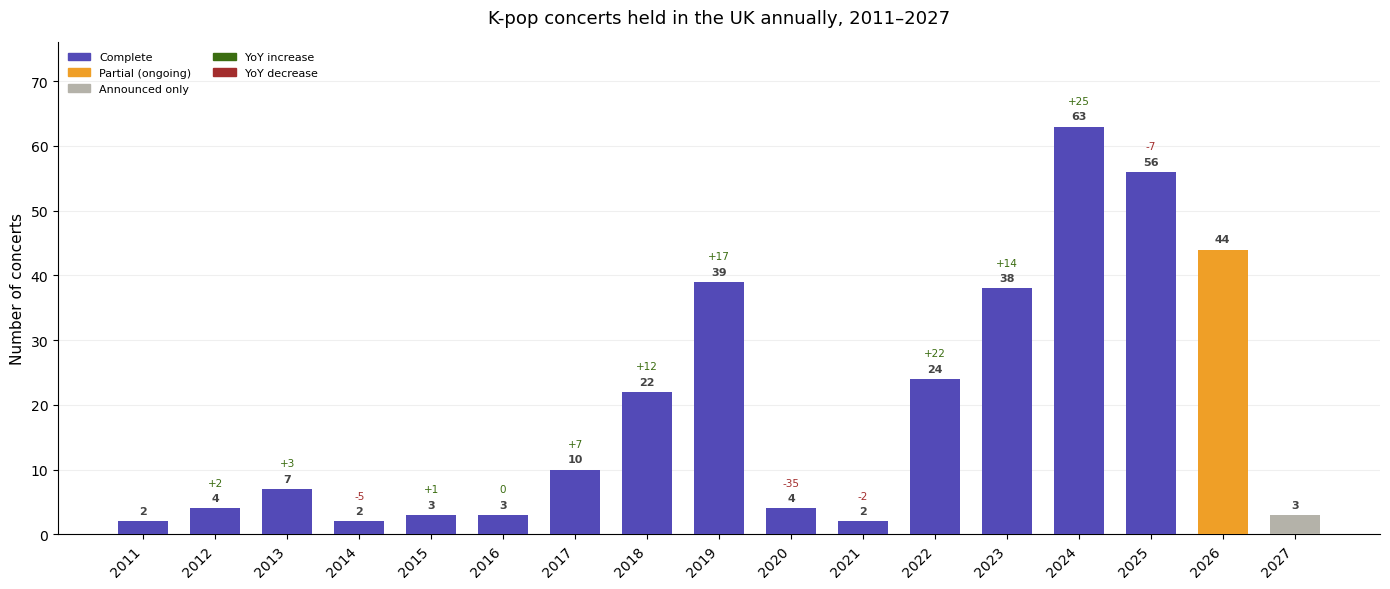

In [569]:
# Creating a bar chart graph of the number of concerts per year from 2011 to 2027 information  


years    = [2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027]
concerts = [2,   4,   7,   2,   3,   3,   10,  22,  39,  4,   2,   24,  38,  63,  56,  44,  3  ]
changes  = [None,2,   3,  -5,   1,   0,   7,   12,  17, -35,  -2,  22,  14,  25,  -7, None, None]
statuses = (["Complete"] * 15) + ["Partial (ongoing)", "Announced only"]

color_map = {
    "Complete":          "#534AB7",
    "Partial (ongoing)": "#EF9F27",
    "Announced only":    "#B4B2A9"
}
colors = [color_map[s] for s in statuses]

fig, ax = plt.subplots(figsize = (14, 6))

bars = ax.bar(years, concerts, color = colors, width = 0.7, zorder = 3)

# Concert count labels on top of each bar
for bar, val in zip(bars, concerts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        str(val),
        ha = "center", va = "bottom", fontsize = 8, color = "#444",
        fontweight = "bold"
    )

# Year-on-year change labels below the concert count
for bar, val, change in zip(bars, concerts, changes):
    if change is None:
        continue
    label = "0" if change == 0 else (f"+{change}" if change > 0 else str(change))
    color = "#3B6D11" if change >= 0 else "#A32D2D"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3.2,       # sits above the count label
        label,
        ha = "center", va = "bottom", fontsize = 7.5, color = color
    )

# Legend
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
legend_patches += [
    mpatches.Patch(color = "#3B6D11", label = "YoY increase"),
    mpatches.Patch(color = "#A32D2D", label = "YoY decrease"),
]
ax.legend(handles = legend_patches, fontsize = 8, frameon = False, loc = "upper left", ncol = 2)

ax.set_xticks(years)
ax.set_xticklabels(years, rotation = 45, ha = "right", fontsize = 10)
ax.set_ylabel("Number of concerts", fontsize = 11)
ax.set_title("K-pop concerts held in the UK annually, 2011–2027", fontsize = 13, pad = 14)
ax.set_ylim(0, 76)
ax.grid(axis = "y", alpha = 0.2, zorder = 0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("kpop_concerts_annual.png", dpi = 150, bbox_inches = "tight")
plt.show()


#### Concert Growth Trend 

From 2011 to 2016, concert activity remained minimal and inconsistent. Annual K-pop concert counts fluctuated between two to seven per year. This suggests that, during this early period, K-pop hadn’t established itself as an international genre in the UK yet, and growth during this period wasn’t yet sustained. <br> 

That changed from 2017 onwards, when concert activity entered a rapid growth period. Concert numbers increased from 10 in 2017 to 22 in 2018, before reaching 39 in 2019. An almost exponential growth. This era marked the first major breakout moment for K-pop in the UK. Audience reach, visibility, and operational scale were all expanding rapidly. <br> 

This momentum was abruptly interrupted by the COVID-19 pandemic in 2020 and 2021, which shut down international touring. Concert figures dropped sharply to single digits, with only a few concerts managing to take place around this time due to restrictions.  This decline is likely due to this worldwide restriction of live events rather than reflecting a decline in UK interest. <br> 

What followed is the most important part of the story. Beginning in 2022, concert growth aggressively returned. 24 concerts in 2022, 38 in 2023, with the number peaking at a staggering 63 in 2024. Even with a slight decline to 56 concerts in 2025, the scale exceeds anything seen before the pandemic. The post-pandemic years aren’t just recovery; they suggest that K-pop in the UK has entered a more mature stage of growth. 

 

In [571]:
# Google Trends — UK Search Interest For K-pop
# It retrieves weekly UK search interest for 'K-pop' from 2011 to 2025 which is used 
# as an external proxy for public awareness, independent of the concert dataset, 
# to test whether interest tracks concert growth.

 
pytrends = TrendReq(hl = "en-GB", tz = 0)
 
try:
    pytrends.build_payload(
        ["K-pop"],
        cat = 0,
        timeframe = "2011-01-01 2025-12-31",
        geo = "GB",
        gprop = ""
    )
    kpop_trends_weekly = pytrends.interest_over_time()
 
    if "isPartial" in kpop_trends_weekly.columns:
        kpop_trends_weekly = kpop_trends_weekly.drop(columns = ["isPartial"])
 
    # Resample to annual average for merging with concert counts
    kpop_trends_annual = (
        kpop_trends_weekly
        .resample("YE")
        .mean()
        .reset_index()
    )
    kpop_trends_annual.columns = ["date", "search_interest"]
    kpop_trends_annual["year"] = kpop_trends_annual["date"].dt.year
 
    print("✓ Google Trends data fetched")
    print(kpop_trends_annual[["year", "search_interest"]].to_string(index = False))
 
except Exception as e:
    print(f" Google Trends fetch failed: {e}")
    print("  Creating placeholder — re-run this cell to retry.")
    kpop_trends_annual = pd.DataFrame({"year": range(2011, 2026), "search_interest": [None] * 15})
 
print()

print("All years accounted for: 2011-2025")

✓ Google Trends data fetched
 year  search_interest
 2011         2.083333
 2012         3.916667
 2013         2.250000
 2014         1.833333
 2015         1.916667
 2016         1.833333
 2017         1.750000
 2018         2.416667
 2019         3.166667
 2020         3.916667
 2021         3.916667
 2022         4.000000
 2023         4.666667
 2024         6.083333
 2025        43.416667

All years accounted for: 2011-2025


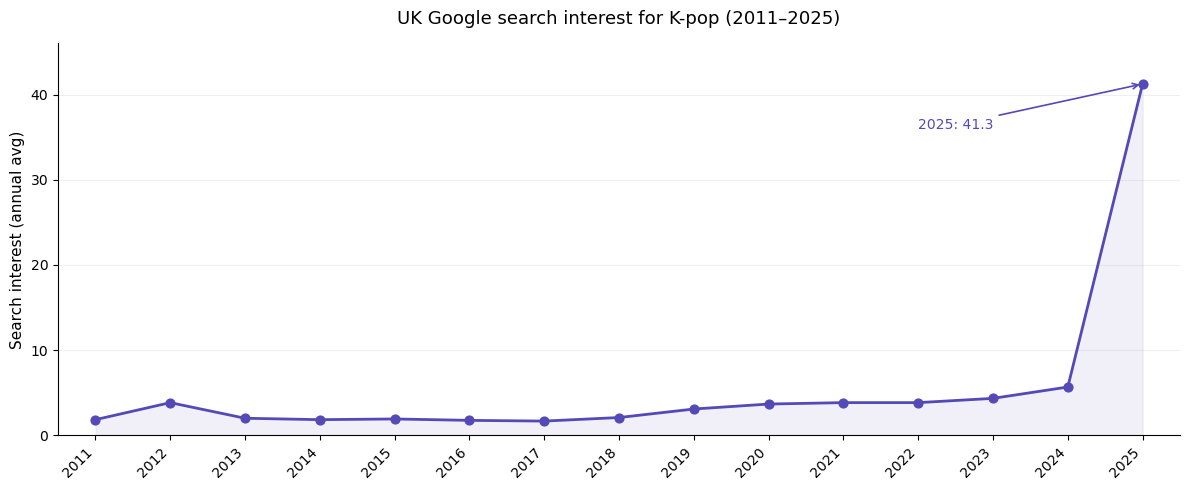

In [572]:
# Line graph for UK Google search interest of K-pop


years          = list(range(2011, 2026))
search_interest = [1.833333, 3.833333, 2.000000, 1.833333, 1.916667,
                   1.750000, 1.666667, 2.083333, 3.083333, 3.666667,
                   3.833333, 3.833333, 4.333333, 5.666667, 41.250000]

fig, ax = plt.subplots(figsize = (12, 5))

ax.plot(years, search_interest, color = "#534AB7", linewidth = 2, zorder = 3)
ax.fill_between(years, search_interest, alpha = 0.08, color = "#534AB7")
ax.scatter(years, search_interest, color = "#534AB7", s = 40, zorder = 4)

# Annotate the 2025 spike
ax.annotate(
    "2025: 41.3",
    xy = (2025, 41.25),
    xytext = (2022, 36),
    fontsize = 10,
    color = "#534AB7",
    arrowprops = dict(arrowstyle = "->", color = "#534AB7", lw = 1.2)
)

ax.set_xlim(2010.5, 2025.5)
ax.set_ylim(0, 46)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation = 45, ha = "right", fontsize = 10)
ax.set_ylabel("Search interest (annual avg)", fontsize = 11)
ax.set_title("UK Google search interest for K-pop (2011–2025)", fontsize = 13, pad = 14)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f"))
ax.grid(axis = "y", alpha = 0.2)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("kpop_search_interest.png", dpi = 150, bbox_inches = "tight")
plt.show()

#### Search Interest Trend 

Search interest follows a different trajectory. Unlike concert growth, online attention remained relatively stable for nearly a decade, fluctuating only slightly between 2011 and 2022 despite rapid growth in live performances after 2017. This suggest that audience growth initially developed through live engagement and long-term fan demand for these artists to tour the UK, rather than through widespread online visibility. <br> 

The turning point came around 2023 when online attention started rising steadily. It increased in 2024 to 5.67 before exploding in 2025 to 41.25. This likely reflects the genre’s transition from a niche fandom into mainstream cultural visibility, driven by growing concert activity in the UK. This alongside the growing influence of TikTok, streaming, and increased hallyu awareness, helped drive wider public interest in K-pop. 



Taken together, these two growth trends reveal an important pattern. Concert growth first, then search growth. Real-world expansion appears to have established this supply of K-pop concerts in the UK we now see, rather than large-scale online attention. This sequence often points to a stronger and more sustainable growth model built on genuine audience engagement rather than short-term hype. Earlier growth seemed to mainly come from dedicated fan communities, whereas 2025 appears to represent a broader, more mainstream interest. 

In [575]:
# Web Scraping: Venue Capacities From Wikipedia 
# For each unique venue, this scrapes the Wikipedia infobox to extract the stated capacity. 
# A polite delay is included between requests so the scraping runs.
# Venues not found on Wikipedia are filled in from the manual lookup table.


# The 5 venues we will attempt to scrape from Wikipedia 
SCRAPE_TARGETS = {
    "Wembley Stadium":          "Wembley_Stadium",
    "Tottenham Hotspur Stadium":"Tottenham_Hotspur_Stadium",
    "The O2 Arena":             "The_O2_Arena",
    "OVO Arena Wembley":        "OVO_Arena_Wembley",
    "O2 Academy Islington":     "O2_Academy_Islington",
}

def scrape_wikipedia_capacity(wikipedia_slug):
    """
    Scrapes the capacity from a Wikipedia article infobox using a direct URL.
    wikipedia_slug is the exact article title with underscores e.g. 'Wembley_Stadium'.
    Returns an integer capacity or None if not found.
    """
    url     = f"https://en.wikipedia.org/wiki/{wikipedia_slug}"
    headers = {"User-Agent": "Mozilla/5.0 (academic research project, student use)"}

    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code != 200:
            print(f"  ✗ HTTP {response.status_code} for {wikipedia_slug}")
            return None

        soup = BeautifulSoup(response.text, "html.parser")

        # Find the infobox — Wikipedia uses vcard class for venue infoboxes
        infobox = (
            soup.find("table", {"class": "infobox vcard"})
            or soup.find("table", {"class": lambda c: c and "infobox" in c})
        )

        if not infobox:
            print(f"  ✗ No infobox found for {wikipedia_slug}")
            return None

        for row in infobox.find_all("tr"):
            header = row.find("th")
            data   = row.find("td")

            if header and data and "capacity" in header.get_text(strip=True).lower():
                # Strip footnote references e.g. [1] before extracting numbers
                clean_text = re.sub(r"\[.*?\]", "", data.get_text(strip=True))
                numbers    = re.findall(r"[\d,]+", clean_text)

                if numbers:
                    capacity = int(numbers[0].replace(",", ""))
                    return capacity

        print(f"  ✗ Infobox found but no capacity row for {wikipedia_slug}")
        return None

    except Exception as e:
        print(f"  ✗ Error scraping {wikipedia_slug}: {e}")
        return None


# Run the scrape for the 5 target venues 
print("Scraping Wikipedia capacities for key venues...")
print("(Direct article URLs used for reliability)\n")

scraped_capacities = {}

for venue_name, slug in SCRAPE_TARGETS.items():
    print(f"  Fetching: {venue_name}...")
    capacity = scrape_wikipedia_capacity(slug)

    if capacity:
        print(f"  ✓ {venue_name}: {capacity:,}")
        scraped_capacities[venue_name] = capacity
    else:
        print(f"  — {venue_name}: not found, will use manual fallback")

    time.sleep(1.5)   # polite delay between requests

print(f"\nSuccessfully scraped {len(scraped_capacities)}/5 venues from Wikipedia\n")


# Manual fallback for all other venues 
manual_capacities = {
    # Stadiums
    "Wembley Stadium":              90000,
    "Tottenham Hotspur Stadium":    62850,
    # Arenas
    "The O2 Arena":                 20000,
    "OVO Arena Wembley":            12500,
    "AO Arena":                     21000,
    "Genting Arena":                15685,
    "Glastonbury Festival":         200000,  # festival capacity
    # Large venues
    "Eventim Apollo":                5039,
    "O2 Academy Brixton":            4921,
    "BST Hyde Park":                65000,   # festival
    "Reading Festival":             105000,  # festival
    # Mid-size
    "Troxy":                         2500,
    "O2 Forum Kentish Town":         2200,
    "O2 Shepherd's Bush Empire":     2000,
    "Indigo at The O2":              2800,
    "Electric Ballroom":             1500,
    "O2 Ritz":                       1600,
    "KOKO":                          1500,
    "Scala":                         1100,
    "Clapham Grand":                 1000,
    "Heaven":                        1500,
    "Barrowland Ballroom":           1900,
    "The Barrowland Ballroom":       1900,
    "O2 Academy Glasgow":            2500,
    "O2 Victoria Warehouse":         3000,
    "O2 Academy Birmingham":         3000,
    "Manchester Academy":            1800,
    "Electric Brixton":              1400,
    "The Classic Grand":              500,
    # Smaller venues
    "O2 Academy Islington":           800,
    "ULU Live":                        800,
    "Classic Grand":                        800,
    "XOYO":                            700,
    "The Garage":                      600,
    "EartH Hall":                      600,
    "The Underworld, Camden":          550,
    "Oval Space":                      800,
    "Dingwalls":                       500,
    "The Lafayette":                   400,
    "Camden Assembly":                 250,
    "229 The Venue":                   350,
    "Islington Assembly Hall":         800,
    "The Courtyard Theatre":           200,
    "Oslo Hackney":                    350,
    "The Lexington":                   200,
    "Strongroom Bar":                  150,
    "Studio 9294":                     300,
    "New Cross In":                    300,
    "The lower third":                 250,
    "The Mirror Arch":                 300,
    "The Steel Yard":                 2000,
    "Outernet":                       1500,
    "Brixton Jamm":                    500,
    "The Dome":                        800,
    "Conway Hall":                     450,
    "Ministry of Sound":              1700,
    "Olympia":                        4000,
    "Fire Nightclub":                  800,
    "Area Manchester":                1000,
    "The Fiddler's Elbow":             200,
    "Lightbox":                        800,
    "Headrow House":                   900,
    "The Lanes":                       300,
    "Shackelwell Arms":                200,
    "Streatham Space Project":         300,
    "Old Billingsgate":               2500,
    "Samsung KX":                      300,
    "The Castle & Falcon":             300,
    "Rebellion Manchester":            600,
    "Kingfisher Centre":               500,
    "Lower Deck, Greenwich Students Union": 200,
    "Fire & Lightbox Complex":         800,
    "The Coronet Theatre":             900,
    "Odeon West End Theatre":         1000,
    "The Forum":                      2300,
    "Canva":                           500,
    "The Lower Third":                 250,
    "Islington Assembly Hall":         950,
    "229":                             620,
}


# Combine scraped + manual into one lookup 
# Scraped results take priority; manual fills everything else
all_capacities = {**manual_capacities, **scraped_capacities}


# Build venue_capacities dataframe and merge onto concerts_main 
unique_venues = (
    concerts_main[["venue", "city"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

venue_capacities = unique_venues.copy()
venue_capacities["capacity_wiki"]   = venue_capacities["venue"].map(scraped_capacities)
venue_capacities["capacity"]        = venue_capacities["venue"].map(all_capacities)

# Summary
wiki_hits = venue_capacities["capacity_wiki"].notna().sum()
manual_hits = venue_capacities["capacity"].notna().sum() - wiki_hits
still_missing = venue_capacities["capacity"].isna().sum()

print("── Capacity resolution summary ─────────────────────────────────")
print(f"  Wikipedia scrape:   {wiki_hits} venues")
print(f"  Manual fallback:    {manual_hits} venues")
print(f"  Still missing:      {still_missing} venues")
print("────────────────────────────────────────────────────────────────\n")

if still_missing > 0:
    print("Venues with no capacity found:")
    print(venue_capacities[venue_capacities["capacity"].isna()]["venue"].tolist())

# Merge onto main dataset
concerts_main = concerts_main.merge(
    venue_capacities[["venue", "capacity"]],
    on="venue",
    how="left"
)

print("✓ Capacity column added to concerts_main")
print(concerts_main[["artist", "venue", "capacity"]].head(10))


Scraping Wikipedia capacities for key venues...
(Direct article URLs used for reliability)

  Fetching: Wembley Stadium...
  ✓ Wembley Stadium: 90,000
  Fetching: Tottenham Hotspur Stadium...
  ✓ Tottenham Hotspur Stadium: 62,850
  Fetching: The O2 Arena...
  ✓ The O2 Arena: 20,000
  Fetching: OVO Arena Wembley...
  ✗ HTTP 403 for OVO_Arena_Wembley
  — OVO Arena Wembley: not found, will use manual fallback
  Fetching: O2 Academy Islington...
  ✗ HTTP 403 for O2_Academy_Islington
  — O2 Academy Islington: not found, will use manual fallback

Successfully scraped 3/5 venues from Wikipedia

── Capacity resolution summary ─────────────────────────────────
  Wikipedia scrape:   3 venues
  Manual fallback:    72 venues
  Still missing:      3 venues
────────────────────────────────────────────────────────────────

Venues with no capacity found:
['Factory', '', 'Reading and Leeds Festival']
✓ Capacity column added to concerts_main
                                     artist                   

In [576]:
# Venue Tier Classification 
# Groups venues into four tiers by capacity which are used throughout
# the analysis as a proxy for the scale and mainstream reach of each concert.

 
def classify_venue_tier(capacity):
    if pd.isna(capacity):
        return "Unknown"
    elif capacity < 1_000:
        return "Small (< 1,000)"
    elif capacity < 5_000:
        return "Mid-tier (1,000–5,000)"
    elif capacity < 20_000:
        return "Arena (5,000–20,000)"
    else:
        return "Stadium / Festival (20,000+)"
 
concerts_main["venue_tier"] = concerts_main["capacity"].apply(classify_venue_tier)
 
tier_counts = concerts_main["venue_tier"].value_counts()
print("✓ Venue Tiers Assigned")
print(tier_counts.to_string())
print() 


✓ Venue Tiers Assigned
venue_tier
Mid-tier (1,000–5,000)          121
Small (< 1,000)                  94
Arena (5,000–20,000)             32
Stadium / Festival (20,000+)     32
Unknown                           3



In [577]:
# Merge Trends With Concert Counts
# Combines annual concert counts with Google search interest into one clean dataframe ready for plotting and regression.
 
concerts_per_year = (
    concerts_main
    .groupby("year")
    .size()
    .reset_index(name = "concert_count")
)
 
# Also compute average capacity per year (excludes unknowns)
avg_capacity_per_year = (
    concerts_main
    .groupby("year")["capacity"]
    .mean()
    .reset_index(name = "avg_capacity")
)
 
# Merge everything together
annual = (
    concerts_per_year
    .merge(avg_capacity_per_year, on = "year", how = "left")
    .merge(kpop_trends_annual[["year", "search_interest"]], on = "year", how = "left")
)
 
print("✓ Annual Summary Table")
print(annual.to_string(index = False))
print()


✓ Annual Summary Table
 year  concert_count  avg_capacity  search_interest
 2011              2   2960.500000         2.083333
 2012              4   7650.000000         3.916667
 2013              7   4625.428571         2.250000
 2014              2   3560.500000         1.833333
 2015              3   1766.666667         1.916667
 2016              3    833.333333         1.833333
 2017             11   4230.454545         1.750000
 2018             22   2110.863636         2.416667
 2019             40   7976.179487         3.166667
 2020              4   7105.250000         3.916667
 2021              2    650.000000         3.916667
 2022             24   5690.125000         4.000000
 2023             38   7532.315789         4.666667
 2024             64   8370.000000         6.083333
 2025             56  11096.685185        43.416667



=== Regression 1: Search interest → Average venue capacity ===

  Full model — with 2025 (n = 15)
    Slope:     196.09
    R²:        0.373
    p-value:   0.0155  (significant at p<0.05)

  Sensitivity check — without 2025 (n = 14)
    Slope:     1561.99
    R²:        0.495
    p-value:   0.0050  (significant at p<0.05)

  Sensitivity analysis interpretation:
  ✓ Result holds even without 2025. The relationship is robust.


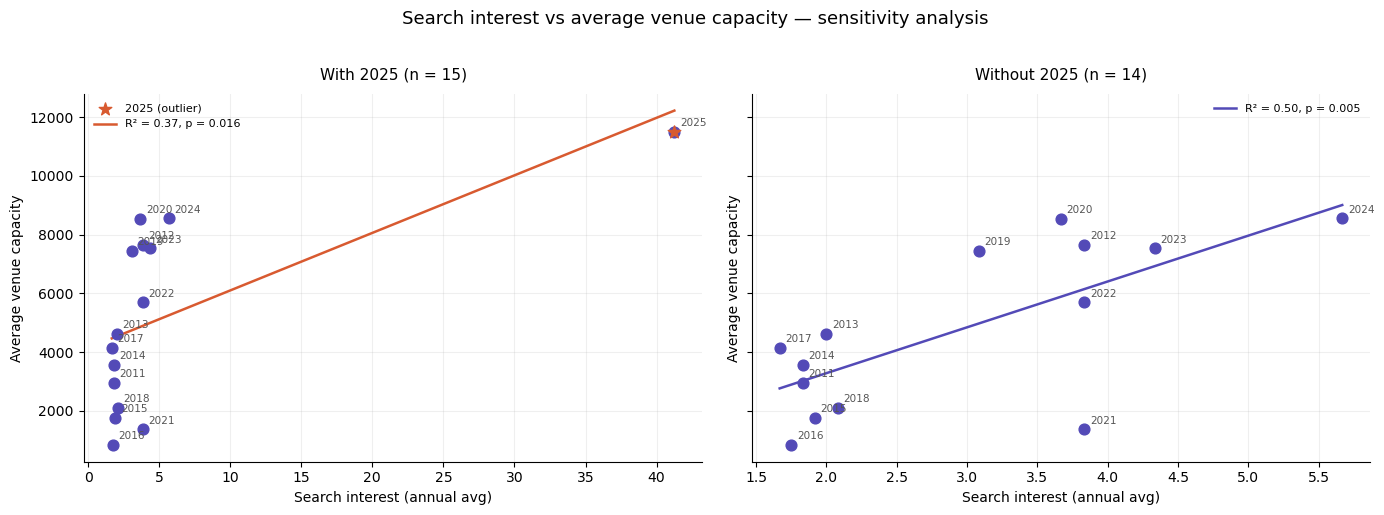

In [578]:
# Regression No.1 of the information displayed above: Does search interest predict average venue size?
# avg_capacity ~ search_interest
# Includes sensitivity analysis to test whether 2025 outlier impacts the result.


# Data 
annual = pd.DataFrame({
    "year":           [2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025],
    "concert_count":  [2,   4,   7,   2,   3,   3,   17,  22,  46,  3,   3,   24,  38,  70,  56  ],
    "avg_capacity":   [2960.5, 7650.0, 4625.4, 3560.5, 1766.7, 833.3, 4149.1,
                       2097.2, 7446.0, 8540.3, 1366.7, 5690.1, 7532.3, 8557.8, 11497.5],
    "search_interest":[1.833, 3.833, 2.000, 1.833, 1.917, 1.750, 1.667,
                       2.083, 3.083, 3.667, 3.833, 3.833, 4.333, 5.667, 41.250]
})

full = annual.copy()
excl = annual[annual["year"] != 2025].copy()

# Running both regressions 
def run_regression(df, label):
    slope, intercept, r, p, se = stats.linregress(
        df["search_interest"], df["avg_capacity"]
    )
    print(f"  {label}")
    print(f"    Slope:     {slope:.2f}")
    print(f"    R²:        {r**2:.3f}")
    print(f"    p-value:   {p:.4f}  ({'significant' if p < 0.05 else 'NOT significant'} at p<0.05)")
    print()
    return slope, intercept, r**2, p

print("=== Regression 1: Search interest → Average venue capacity ===\n")
slope_full, int_full, r2_full, p_full = run_regression(full, "Full model — with 2025 (n = 15)")
slope_excl, int_excl, r2_excl, p_excl = run_regression(excl, "Sensitivity check — without 2025 (n = 14)")

# Interpretation 
print("  Sensitivity analysis interpretation:")
if p_excl >= 0.05 and p_full < 0.05:
    print("    Result is driven by 2025. Without it the relationship is NOT")
    print("    significant — the outlier is doing all the work.")
elif p_excl < 0.05 and p_full < 0.05:
    print("  ✓ Result holds even without 2025. The relationship is robust.")
else:
    print("  Neither model is significant — search interest does not reliably")
    print("    predict venue size in this dataset.")

# Plotting the results side by side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5), sharey = True)

def scatter_and_line(ax, df, slope, intercept, r2, p, highlight_2025 = False, title = ""):
    # Points
    ax.scatter(df["search_interest"], df["avg_capacity"],
               color = "#534AB7", s = 60, zorder = 3)

    # 2025 highlighted if included
    if highlight_2025:
        ax.scatter(
            full.loc[full["year"]==2025, "search_interest"],
            full.loc[full["year"]==2025, "avg_capacity"],
            color = "#D85A30", s = 90, zorder = 4, marker = "*", label = "2025 (outlier)"
        )

    # Year labels
    for _, row in df.iterrows():
        ax.annotate(str(int(row["year"])),
                    xy = (row["search_interest"], row["avg_capacity"]),
                    xytext = (4, 4), textcoords = "offset points",
                    fontsize = 7.5, color = "#555")

    # Regression line
    x_line = np.linspace(df["search_interest"].min(), df["search_interest"].max(), 200)
    color  = "#D85A30" if highlight_2025 else "#534AB7"
    ax.plot(x_line, slope * x_line + intercept,
            color = color, linewidth = 1.8,
            label = f"R² = {r2:.2f}, p = {p:.3f}")

    ax.set_xlabel("Search interest (annual avg)", fontsize = 10)
    ax.set_ylabel("Average venue capacity", fontsize = 10)
    ax.set_title(title, fontsize = 11, pad = 10)
    ax.legend(fontsize = 8, frameon = False)
    ax.grid(alpha = 0.2)
    ax.spines[["top", "right"]].set_visible(False)

scatter_and_line(ax1, full, slope_full, int_full, r2_full, p_full,
                 highlight_2025 = True, title = "With 2025 (n = 15)")

scatter_and_line(ax2, excl, slope_excl, int_excl, r2_excl, p_excl,
                 highlight_2025 = False, title = "Without 2025 (n = 14)")

fig.suptitle("Search interest vs average venue capacity — sensitivity analysis",
             fontsize = 13, y = 1.02)

plt.tight_layout()
plt.savefig("regression1_with_sensitivity.png", dpi = 150, bbox_inches = "tight")
plt.show()

#### Regression 1: Simple Linear Regression 

A linear regression of Google search interest against average venue capacity found that every 1-point rise in search interest is associated with venues being 196 seats larger on average (slope = 196, R² = 0.37, p = 0.016). A sensitivity analysis excluding the 2025 outlier (41.25 spike, against a 2011–2024 average of 2.9), confirmed the result was robust. The relationship actually strengthened (slope = 1562, R² = 0.50, p = 0.005). This suggests that rising mainstream interest is associated with artists performing in progressively larger venues, independent of the one anomalous year. <br> 

However, this result should still be interpreted carefully. With only 15 annual observations, statistical power is limited. Simple linear regression doesn’t account for other confounding factors that influence venue selection — such as how popular an artist is or promoter decisions. Average venue capacity doesn’t tell us the actual number of tickets sold. A 20,000-capacity arena may sell only half of its seats, whereas a small venue may have sold out 5 minutes after the tickets go live. Findings should be treated as suggestive not conclusive. 
Search interest therefore may reflect cultural visibility rather than direct commercial demand. We would need to include actual ticket sales data to say more confidently that one causes the other.




=== Regression 2: Concert count ~ search interest + avg capacity ===
  Intercept:              -2.92
  Coeff (search_interest): 0.36  (concerts per 1-unit rise in search interest)
  Coeff (avg_capacity):    0.0040  (concerts per 1-unit rise in avg capacity)
  R²:                     0.465  (46.5% of variance explained)
  Adjusted R²:            0.376  (penalised for 2 predictors, n = 15)

  Note: with only 15 observations and 2 predictors, interpret
  adjusted R² rather than R² — overfitting risk is real here.


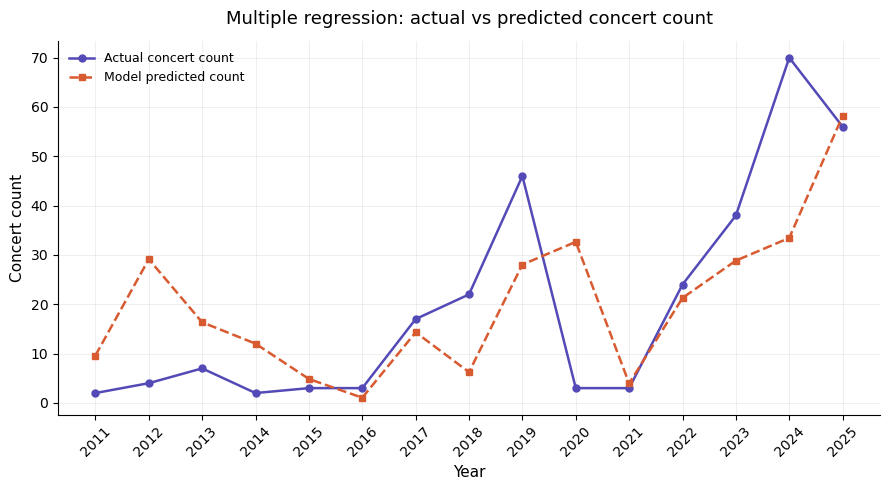

In [580]:
# Regression No.2: Multiple regression — concert count ~ search interest + avg capacity


X = annual[["search_interest", "avg_capacity"]].values
y = annual["concert_count"].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
r2     = r2_score(y, y_pred)
n      = len(y)
k      = X.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)   # adjusted R² penalises extra predictors

print("=== Regression 2: Concert count ~ search interest + avg capacity ===")
print(f"  Intercept:              {model.intercept_:.2f}")
print(f"  Coeff (search_interest): {model.coef_[0]:.2f}  (concerts per 1-unit rise in search interest)")
print(f"  Coeff (avg_capacity):    {model.coef_[1]:.4f}  (concerts per 1-unit rise in avg capacity)")
print(f"  R²:                     {r2:.3f}  ({r2*100:.1f}% of variance explained)")
print(f"  Adjusted R²:            {adj_r2:.3f}  (penalised for 2 predictors, n = 15)")
print()
print("  Note: with only 15 observations and 2 predictors, interpret")
print("  adjusted R² rather than R² — overfitting risk is real here.")

# Actual vs predicted plot 
fig, ax = plt.subplots(figsize = (9, 5))

ax.plot(annual["year"], y,      color = "#534AB7", marker = "o", linewidth = 1.8,
        markersize = 5, label = "Actual concert count")
ax.plot(annual["year"], y_pred, color="#D85A30", marker = "s", linewidth = 1.8,
        markersize = 5, linestyle = "--", label = "Model predicted count")

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Concert count", fontsize=11)
ax.set_title("Multiple regression: actual vs predicted concert count", fontsize = 13, pad = 12)
ax.legend(fontsize = 9, frameon = False)
ax.grid(alpha = 0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(annual["year"])
ax.tick_params(axis = "x", rotation = 45)

plt.tight_layout()
plt.savefig("regression2_multiple.png", dpi = 150, bbox_inches = "tight")
plt.show()

#### Regression 2: Multiple Regression 
A multiple regression using both search interest and average venue capacity to predict annual concert count explained 37.6% of the variance (adjusted R² = 0.376, n=15). Search interest was clearly the stronger predictor (β = 0.36) as each additional point of search interest is associated with roughly 0.36 more concerts that year. Average venue capacity added very little to it (β = 0.004), and the adjusted R² barely moved compared to the single-predictor model (0.373 to 0.376). Knowing how large the venues are tells us little about concert volume beyond what search interest already explains. <br> 

And the model has real limits. With only 15 data points and 2 predictors, the results should be treated as exploratory rather than definitive. It's also worth considering that concert count and venue size doesn’t always reflect true demand. An artist might draw enough demand for an arena show but end up in a mid-tier venue simply because the arena was unavailable.




In [582]:
# For geographical anaylsis: London vs. Rest of the UK. 
# Used to analyse geographic spread over time.
 
concerts_main["is_london"] = (concerts_main["city"] == "London").astype(int)
 
london_pct = concerts_main["is_london"].mean() * 100
print(f"✓ Concert location is London")
print(f"  {london_pct:.1f}% of concerts (2011–2025) were held in London\n") 

# Get the numbers needed for the pie chart
print(concerts_main["is_london"].value_counts())
print()
print(concerts_main[concerts_main["is_london"] == 0]["city"].value_counts())

✓ Concert location is London
  89.4% of concerts (2011–2025) were held in London

is_london
1    252
0     30
Name: count, dtype: int64

city
Manchester     16
Glasgow         5
Birmingham      3
Dublin          2
Glastonbury     1
Bristol         1
Leeds           1
Reading         1
Name: count, dtype: int64


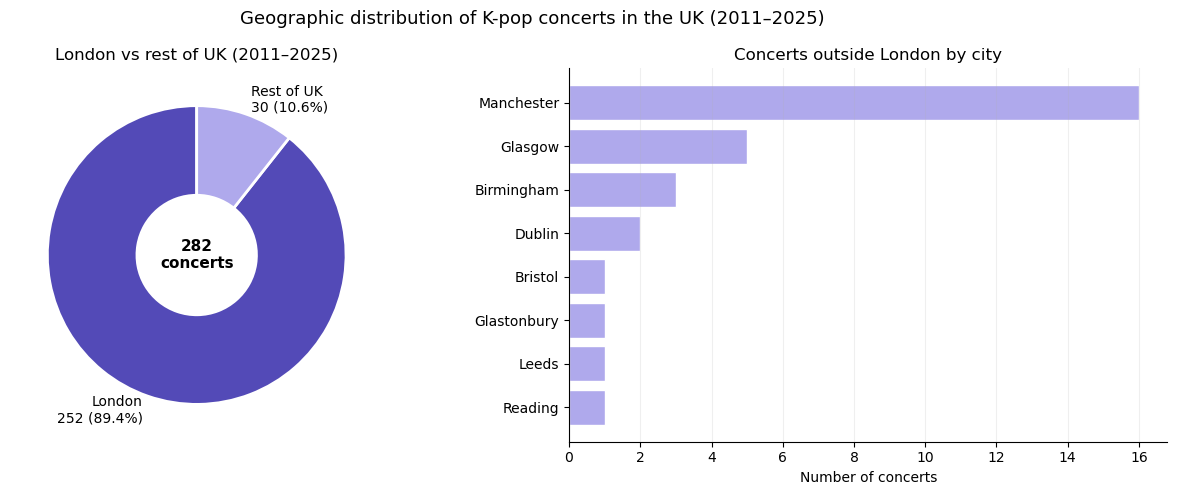

In [583]:
# Creating the graphical representation of geographic distribution of K-pop concerts in the UK.  
# Pie chart: London vs Rest of UK  


fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (13, 5))

pie_labels = ["London\n252 (89.4%)", "Rest of UK\n30 (10.6%)"]
pie_values = [252, 30]
pie_colors = ["#534AB7", "#AFA9EC"]

ax1.pie(
    pie_values,
    labels = pie_labels,
    colors = pie_colors,
    startangle = 90,
    wedgeprops = dict(edgecolor = "white", linewidth = 2, width = 0.6)
)

ax1.text(0, 0, "282\nconcerts", ha = "center", va = "center",
         fontsize = 11, fontweight = "bold")

ax1.set_title("London vs rest of UK (2011–2025)", fontsize = 12)


# Bar chart: cities outside London 
cities = ["Reading", "Leeds", "Glastonbury", "Bristol",
          "Dublin", "Birmingham", "Glasgow", "Manchester"]
counts = [1, 1, 1, 1, 2, 3, 5, 16]

ax2.barh(cities, counts, color = "#AFA9EC", edgecolor = "white")
ax2.set_xlabel("Number of concerts")
ax2.set_title("Concerts outside London by city", fontsize = 12)
ax2.grid(axis = "x", alpha = 0.2)
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("Geographic distribution of K-pop concerts in the UK (2011–2025)", fontsize = 13)
plt.tight_layout()
plt.savefig("kpop_geography.png", dpi = 150, bbox_inches = "tight")
plt.show()

#### Geographic Distribution 

The geographic distribution of K-pop concerts in the UK is unsurprisingly London-centric. Between 2011 and 2025, 89.4% of all concerts (252 out of 282) took place in London. This is consistent with how most European K-pop tours allocate typically only one stop per country. Outside London, Manchester is the only city with a meaningful number of shows at 16, but these are typically alongside a London date. Bristol, Leeds, Reading and Glastonbury each hosted just a single show across the entire 15-year period, as the artists were part of a festival lineup. Dublin appears twice in the data but is technically outside the UK. It is included here as K-pop promoters often bundle Irish dates into UK tours rather than treating them separately. <br> 

Geographic distribution matters because if K-pop has truly gone mainstream in the UK, one might expect concerts to be spreading more evenly across major cities, the way established Western artists tend to tour. However, it can also be said that established Western artists tend to do only multiple nights in London. The data suggests that for now, K-pop in the UK remains largely a London phenomenon, with Manchester as a distant but clear second market. 



In [585]:
# Finding out K-pop artists who have come to the UK more than once, the locations, and the (size of) venues they go to

# Top repeat artists — how many times each artist has performed in the UK

repeat_artists = (
    concerts_main["artist"]
    .value_counts()
    .reset_index()
)
repeat_artists.columns = ["artist", "concerts"]
print(repeat_artists.head(10)) 


             artist  concerts
0          Eric Nam        11
1          The Rose         9
2             ATEEZ         7
3         BLACKPINK         7
4     wave to earth         5
5               W24         5
6  Hypnosis Therapy         4
7          Jay Park         4
8      DREAMCATCHER         4
9       Kang Daniel         3


In [586]:
# For the top 5 artists — which venues and cities do they return to?
top_5 = repeat_artists["artist"].head(5).tolist()

for artist in top_5:
    print(f"\n{artist}:")
    artist_data = concerts_main[concerts_main["artist"] == artist]
    print(artist_data[["year", "city", "venue"]].sort_values("year").to_string(index = False))


Eric Nam:
 year       city                     venue
 2019     London      O2 Academy Islington
 2019     London      O2 Academy Islington
 2022    Glasgow   The Barrowland Ballroom
 2022 Manchester                   O2 Ritz
 2022     London     O2 Forum Kentish Town
 2022     London O2 Shepherd's Bush Empire
 2024    Glasgow        O2 Academy Glasgow
 2024     Dublin                   Olympia
 2024     Dublin                   Olympia
 2024 Manchester        Manchester Academy
 2024     London            Eventim Apollo

The Rose:
 year       city                 venue
 2018     London              ULU Live
 2019     London                 Scala
 2019     London                 Scala
 2019 Manchester    Manchester Academy
 2023     London O2 Forum Kentish Town
 2023     London         BST Hyde Park
 2024     London     OVO Arena Wembley
 2025     London      Indigo at The O2
 2025     London      Indigo at The O2

ATEEZ:
 year       city                 venue
 2019     London O2 Forum

In [587]:
# Get year, venue, capacity and city for each of the top 5 artists
top_5 = ["Eric Nam", "The Rose", "ATEEZ", "BLACKPINK", "wave to earth"]

artist_shows = concerts_main[concerts_main["artist"].isin(top_5)][
    ["artist", "year", "city", "venue", "capacity"]
].sort_values(["artist", "year"])

print(artist_shows.to_string(index = False))

       artist  year       city                     venue  capacity
        ATEEZ  2019     London     O2 Forum Kentish Town    2200.0
        ATEEZ  2022     London         OVO Arena Wembley   12500.0
        ATEEZ  2022     London         OVO Arena Wembley   12500.0
        ATEEZ  2023     London              The O2 Arena   20000.0
        ATEEZ  2025     London              The O2 Arena   20000.0
        ATEEZ  2025     London              The O2 Arena   20000.0
        ATEEZ  2025 Manchester                  AO Arena   21000.0
    BLACKPINK  2019 Manchester                  AO Arena   21000.0
    BLACKPINK  2019     London         OVO Arena Wembley   12500.0
    BLACKPINK  2022     London              The O2 Arena   20000.0
    BLACKPINK  2022     London              The O2 Arena   20000.0
    BLACKPINK  2023     London             BST Hyde Park   65000.0
    BLACKPINK  2025     London           Wembley Stadium   90000.0
    BLACKPINK  2025     London           Wembley Stadium   900

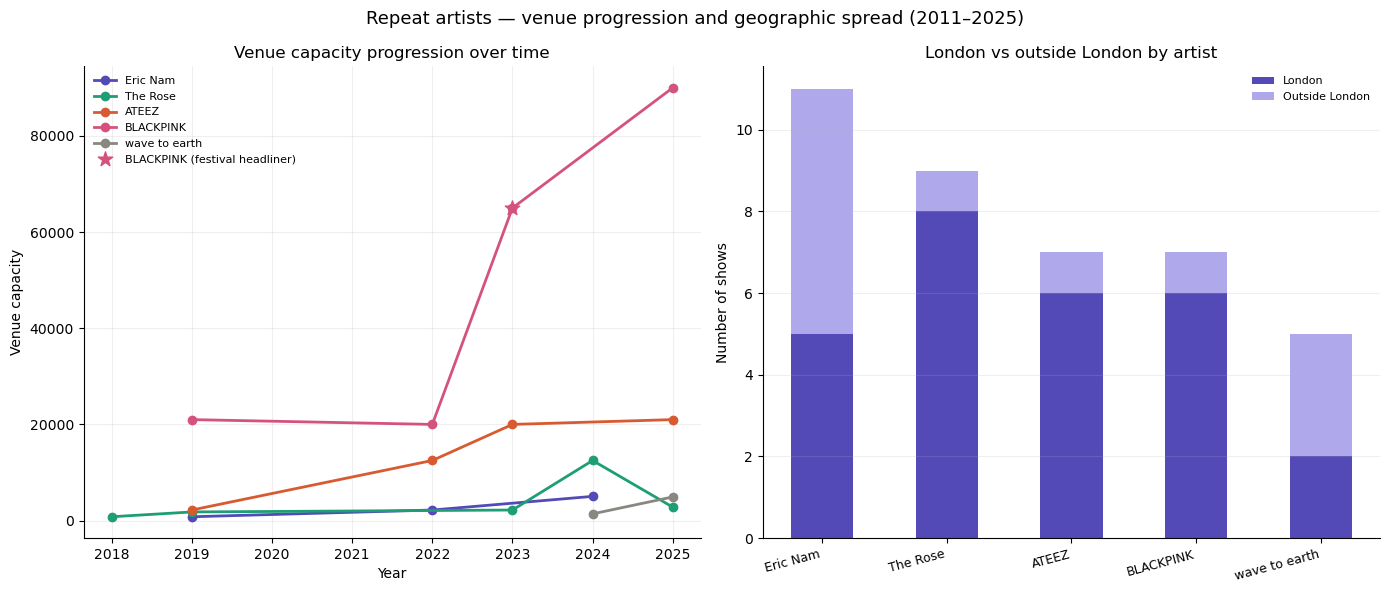

In [588]:
# Repeat Artists: Venue progression and Geographic Spread
# Left graph  — max venue capacity per year per artist
# Right graph — London vs outside London show count per artist

# Note: BST Hyde Park was removed from The Rose as they were a support act for BLACKPINK. 
# The 65,000 capacity isn't theirs.
# But, BST Hyde Park remains for BLACKPINK as they were a headliner of the festival. 


top_5 = ["Eric Nam", "The Rose", "ATEEZ", "BLACKPINK", "wave to earth"]

artist_shows = concerts_main[concerts_main["artist"].isin(top_5)][
    ["artist", "year", "city", "venue", "capacity"]
].sort_values(["artist", "year"])

# Remove BST Hyde Park from The Rose — they were a support act not a headliner
artist_shows_clean = artist_shows[
    ~((artist_shows["artist"] == "The Rose") &
      (artist_shows["venue"] == "BST Hyde Park"))
].copy()

# colours for each artist
artist_colors = {
    "Eric Nam":      "#534AB7",
    "The Rose":      "#1D9E75",
    "ATEEZ":         "#D85A30",
    "BLACKPINK":     "#D4537E",
    "wave to earth": "#888780"
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: venue capacity over time 
for artist in top_5:
    data = artist_shows_clean[artist_shows_clean["artist"] == artist].dropna(subset = ["capacity"])
    yearly_max = data.groupby("year")["capacity"].max().reset_index()
    ax1.plot(yearly_max["year"], yearly_max["capacity"],
             marker = "o", linewidth = 2, markersize = 6,
             color = artist_colors[artist], label = artist)

# BLACKPINK BST Hyde Park has a separate star marker
bst = artist_shows[
    (artist_shows["artist"] == "BLACKPINK") &
    (artist_shows["venue"] == "BST Hyde Park")
]
ax1.scatter(bst["year"], bst["capacity"],
            marker = "*", s = 120, color = artist_colors["BLACKPINK"],
            zorder = 5, label = "BLACKPINK (festival headliner)")

ax1.set_xlabel("Year", fontsize = 10)
ax1.set_ylabel("Venue capacity", fontsize = 10)
ax1.set_title("Venue capacity progression over time", fontsize = 12)
ax1.legend(fontsize = 8, frameon = False)
ax1.grid(alpha = 0.2)
ax1.spines[["top", "right"]].set_visible(False)

# Chart 2: London vs outside of London 
london_counts  = []
outside_counts = []

for artist in top_5:
    data = artist_shows[artist_shows["artist"] == artist]
    london_counts.append((data["city"] == "London").sum())
    outside_counts.append((data["city"] != "London").sum())

x = list(range(len(top_5)))

ax2.bar(x, london_counts, color = "#534AB7", width = 0.5, label = "London")
ax2.bar(x, outside_counts, color = "#AFA9EC", width = 0.5,
        bottom = london_counts, label = "Outside London")

ax2.set_xticks(x)
ax2.set_xticklabels(top_5, fontsize = 9, rotation = 15, ha = "right")
ax2.set_ylabel("Number of shows", fontsize = 10)
ax2.set_title("London vs outside London by artist", fontsize = 12)
ax2.legend(fontsize = 8, frameon = False)
ax2.grid(axis = "y", alpha = 0.2)
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("Repeat artists — venue progression and geographic spread (2011–2025)",
             fontsize = 13)
plt.tight_layout()
plt.savefig("repeat_artists.png", dpi = 150, bbox_inches = "tight")
plt.show()


#### Repeat Artists 

Looking at repeat artists reveals some of the clearest evidence of K-pop's growth in the UK. Eric Nam went from an 800-capacity venue (O2 Academy Islington) in 2019 to the 5,000-capacity Eventim Apollo in 2024, illustrating how returning artists upgrade to larger venues. This pattern is even clearer in ATEEZ's case, as they went from O2 Forum Kentish Town in 2019 to selling out The O2 Arena by 2023; an 18,000-capacity difference in just four years. BLACKPINK represent the ceiling of this trajectory, performing at Wembley Stadium in 2025, the largest venue in the dataset. <br> 

Repeat visits also show artists beginning to move outside London. Eric Nam performed in Glasgow, Manchester and Dublin on his 2022 and 2024 tours, and ATEEZ added a Manchester AO Arena date in 2025. This suggests that as artists build larger UK fanbases, they can geographically expand to serve more fans. <br> 

The Rose started at ULU Live (800 capacity) in 2018 and have steadily progressed through venue size to OVO Arena Wembley (12,500 capacity) in 2024. They performed twice at Indigo at The O2 dates (2,800 capacity) in 2025, which is a different sign of demand (not shown with graph data). They have experienced a slower but upward trajectory. The Rose's 2023 BST Hyde Park appearance is excluded from their venue progression analysis as they performed as a support act, so the 65,000 crowd is not their own. BLACKPINK was a headliner for BST Hyde Park, so this remains in their progression analysis. <br> 

Wave to earth by contrast is more geographically spread. Their 2024 dates hit Manchester and Glasgow before London, with their 2025 dates split between London and Manchester again but perform in similar capacity venues (1,000-2,000). <br> 

It's worth noting that repeat appearances also depend on how long a group has been active. ATEEZ debuted in 2018 so has had fewer years to accumulate UK visits compared to BLACKPINK who debuted in 2016. A group returning three times in five years is arguably a stronger signal of UK fanbase loyalty than a group returning four times across a decade.



In [590]:
# Summary of the information that has been used for this project 

print("=" * 62)
print("COMPLETE CLEANING & SCRAPING — OBJECTS AVAILABLE:")
print("=" * 62)
print("  concerts_main       — full cleaned dataset, 2011–2025")
print("                        columns: artist, date, city, venue,")
print("                                 year, month, is_london,")
print("                                 capacity, venue_tier")
print("  concerts_2026       — partial year, for commentary only")
print("  concerts_future     — 2027+ announced dates")
print("  venue_capacities    — per-venue capacity lookup table")
print("  kpop_trends_weekly  — weekly UK Google search interest")
print("  kpop_trends_annual  — annual average search interest")
print("  annual              — year-level summary for plotting")
print("  London_pct          — Geographic distribution of kpop")  
print("                         concerts: overall percentage of")
print("                         concerts in London vs Cities outside")
print("                         of London, for the years 2011 -2025")
print("  repeat_artists      — K-pop artists who have returned to the") 
print("                         UK for a concert")
print("  top_5               — top 5 k-pop artists who have returned")
print("                         to the UK for a concert")
print("=" * 62)

COMPLETE CLEANING & SCRAPING — OBJECTS AVAILABLE:
  concerts_main       — full cleaned dataset, 2011–2025
                        columns: artist, date, city, venue,
                                 year, month, is_london,
                                 capacity, venue_tier
  concerts_2026       — partial year, for commentary only
  concerts_future     — 2027+ announced dates
  venue_capacities    — per-venue capacity lookup table
  kpop_trends_weekly  — weekly UK Google search interest
  kpop_trends_annual  — annual average search interest
  annual              — year-level summary for plotting
  London_pct          — Geographic distribution of kpop
                         concerts: overall percentage of
                         concerts in London vs Cities outside
                         of London, for the years 2011 -2025
  repeat_artists      — K-pop artists who have returned to the
                         UK for a concert
  top_5               — top 5 k-pop artists who have r

#### So, What Does the Data Actually Tell Us? 

To answer the question: has K-pop in the UK become mainstream? The 15 years of data tells a clear story. <br> 

In the early 2010s, K-pop live events in the UK were sparse having only a handful of shows a year, almost exclusively in London. By the mid-2020s annual concert counts had exploded. 2024 and 2025 hosted the most concerts in the dataset by a significant margin, a fundamentally different scale of activity. In the early years, K-pop acts were playing intimate venues. There has since been a gradual upwards shift of larger venues being played on average. The shift in scale is significant; it’s the difference between a niche fanbase and a mainstream one. <br>  

Google search interest represents a broader cultural shift, that came around 2018-2019 which is often associated with the time of BTS breaking into mainstream Western markets. It rises sharply from 2023 onwards, after years of lagging behind concert growth, suggesting the genre has moved beyond fan communities into wider public awareness. <br> 

Geographic distribution remains limited, London hosting nearly 90% of shows over the years, but it’s starting to spread to Manchester. But repeat artist data signals optimism. Returning artists to the UK typically upgrade their venues, suggesting they are converting casual listeners into committed fans willing to buy tickets again. <br> 

K-pop in the UK isn’t just growing. It appears to be sustaining. 


##### Other Resources: 

[Markdown for Jupyter notebooks cheatsheet](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet) <br> 
^Markdown Notation 

[Table Visualization - pandas documentation](https://pandas.pydata.org/docs/dev/user_guide/style.html) <br> 
^For formatting table output in Jupyter notebook using python code  

[Matplotlib pyplot bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) <br> 
[Matplotlib pyplot barh](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.barh.html) <br> 
^How to plot bar chart 

[Matplotlib pyplot plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)  <br> 
^How to plot line graph 

[Real Python linear regression in Python](https://realpython.com/linear-regression-in-python/) <br> 
[Scikit learn for Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) <br> 
[Codecademy multiple linear regression cheatsheet](https://www.codecademy.com/learn/linear-regression-mssp/modules/multiple-linear-regression-mssp/cheatsheet) <br> 
[GitHub ML reg1](https://tung-dn.github.io/prog_ML_reg1.html) <br> 
^How to do a simple linear regression and multiple regression (*note: had help from AI with the code for multiple regression due to it being more difficult)  

[Matplotlib pie and donut labels](https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html) <br> 
^How to plot a pie chart 
